<h1>SUPPORT VECTOR MACHINE</h1>

<h5>Task 1: Exploratory Data Analysis (EDA)</h5>

In [1]:
import numpy as np
import pandas as pd

In [2]:
# Load the dataset 
df = pd.read_csv("Pharma_Industry.csv")
df

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
0,-0.128538,0.303280,-1.881849,0.258286,-0.792011,1
1,-1.846188,2.865142,-0.929511,2.866786,-0.719447,1
2,-1.252393,-1.541613,0.363632,-0.325370,0.191314,0
3,1.992515,-1.142779,-0.766657,0.975286,-0.823355,1
4,0.377100,0.538410,-0.029263,1.896015,-0.960130,1
...,...,...,...,...,...,...
495,-1.553759,0.506938,0.817890,-0.661245,-1.345393,0
496,0.551476,1.714321,0.340589,1.712558,-0.496315,1
497,-1.072743,-0.221137,0.239247,1.112924,-0.285838,1
498,1.661259,0.245759,-0.457096,0.633355,0.657413,0


In [3]:
df.head()

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
0,-0.128538,0.303280,-1.881849,0.258286,-0.792011,1
1,-1.846188,2.865142,-0.929511,2.866786,-0.719447,1
2,-1.252393,-1.541613,0.363632,-0.325370,0.191314,0
3,1.992515,-1.142779,-0.766657,0.975286,-0.823355,1
4,0.377100,0.538410,-0.029263,1.896015,-0.960130,1


In [4]:
df.shape

(500, 6)

In [5]:
df.columns

Index(['Drug Dosage (mg)', 'Systolic Blood Pressure (mmHg)',
       'Heart Rate (BPM)', 'Liver Toxicity Index (U/L)',
       'Blood Glucose Level (mg/dL)', 'Drug Response'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Drug Dosage (mg)                500 non-null    float64
 1   Systolic Blood Pressure (mmHg)  500 non-null    float64
 2   Heart Rate (BPM)                500 non-null    float64
 3   Liver Toxicity Index (U/L)      500 non-null    float64
 4   Blood Glucose Level (mg/dL)     500 non-null    float64
 5   Drug Response                   500 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 23.6 KB


In [7]:
df.describe()

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.0000
mean,-0.037761,0.214957,0.062871,0.054398,-0.171863,0.5200
std,0.979891,1.247567,0.971978,0.986001,0.983765,0.5001
min,-3.019512,-3.773897,-2.940389,-3.401277,-3.110431,0.0000
25%,-0.642003,-0.565168,-0.648157,-0.586085,-0.797715,0.0000
50%,-0.019340,0.201532,0.027732,-0.065661,-0.108106,1.0000
75%,0.641151,0.951375,0.710774,0.633914,0.513555,1.0000
max,2.949094,4.111751,3.193108,3.373269,2.518023,1.0000


In [10]:
df.isnull().sum()

Drug Dosage (mg)                  0
Systolic Blood Pressure (mmHg)    0
Heart Rate (BPM)                  0
Liver Toxicity Index (U/L)        0
Blood Glucose Level (mg/dL)       0
Drug Response                     0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.dtypes

Drug Dosage (mg)                  float64
Systolic Blood Pressure (mmHg)    float64
Heart Rate (BPM)                  float64
Liver Toxicity Index (U/L)        float64
Blood Glucose Level (mg/dL)       float64
Drug Response                       int64
dtype: object

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

<h5>Histogram</h5>

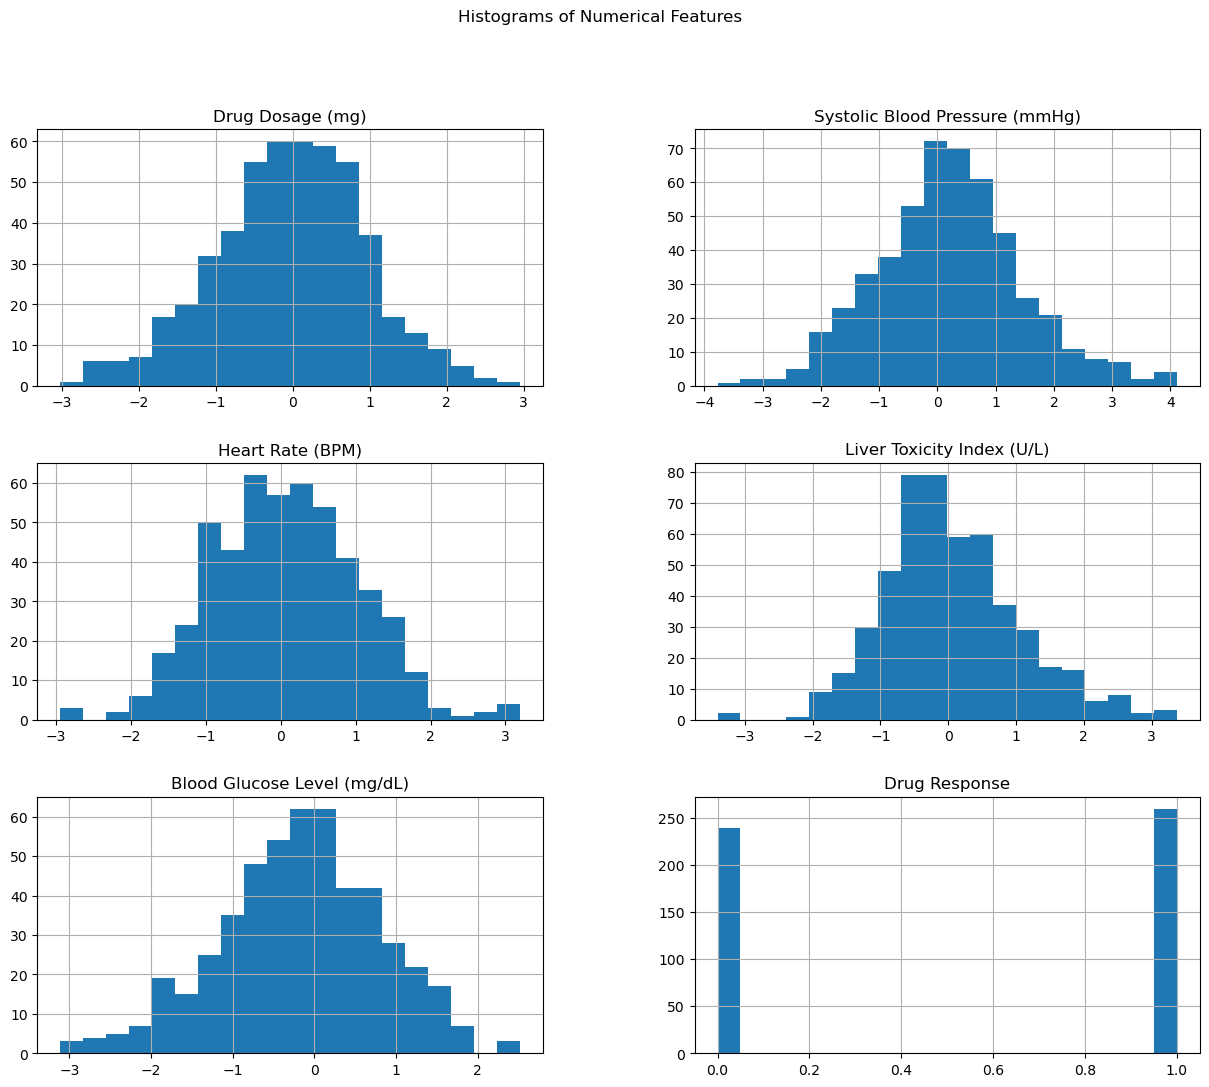

In [17]:
df.hist(figsize=(15,12),bins=20)
plt.suptitle('Histograms of Numerical Features')
plt.show()

<h5>Observation for Histograms</h5>
<h6>Histograms help visualize the spread, shape, and frequency distribution of numerical variables. Some features may appear normally distributed, while others may show skewness or outliers.</h6>

<h5>Boxplots</h5>

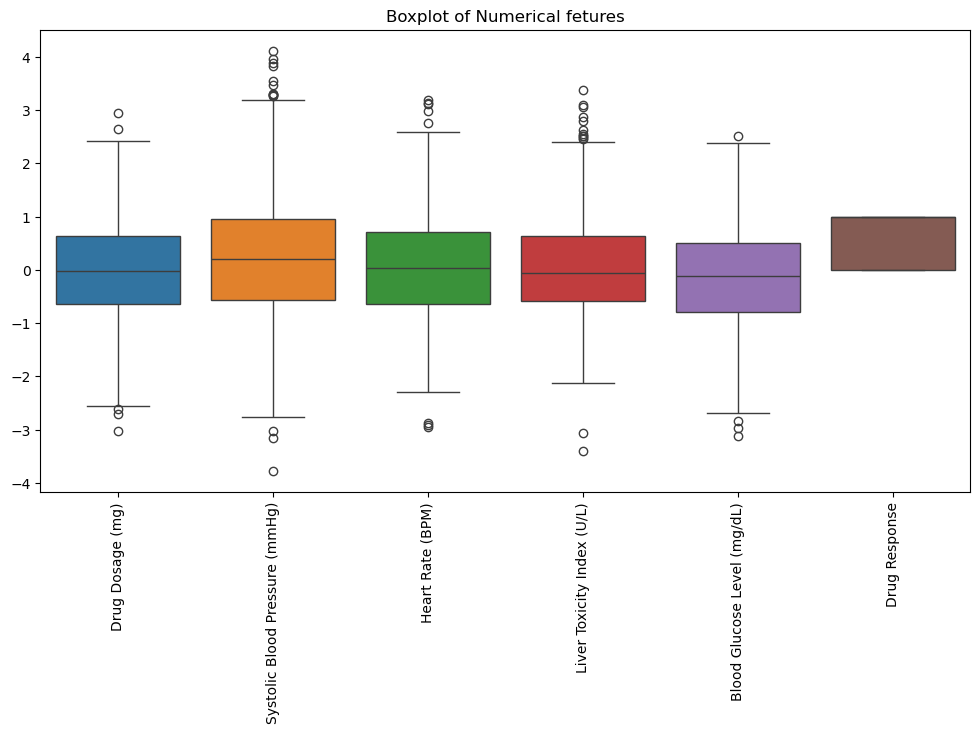

In [19]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.title("Boxplot of Numerical fetures")
plt.show()

<h5>Density Plots</h5>

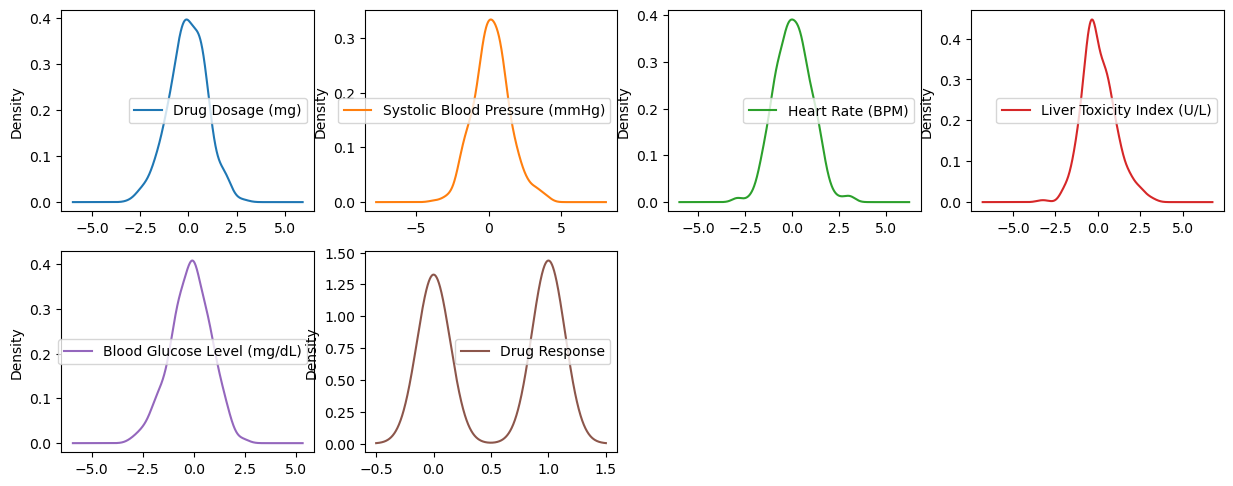

In [20]:
df.plot(kind='density', subplots=True, layout=(4,4), figsize=(15,12), sharex=False)

plt.show()

In [21]:
# correlation matrix
corr_matrix = df.corr()
print(corr_matrix)

                                Drug Dosage (mg)  \
Drug Dosage (mg)                        1.000000   
Systolic Blood Pressure (mmHg)          0.090618   
Heart Rate (BPM)                        0.040571   
Liver Toxicity Index (U/L)              0.128127   
Blood Glucose Level (mg/dL)             0.012434   
Drug Response                           0.043457   

                                Systolic Blood Pressure (mmHg)  \
Drug Dosage (mg)                                      0.090618   
Systolic Blood Pressure (mmHg)                        1.000000   
Heart Rate (BPM)                                     -0.039195   
Liver Toxicity Index (U/L)                            0.283672   
Blood Glucose Level (mg/dL)                           0.037228   
Drug Response                                         0.305226   

                                Heart Rate (BPM)  Liver Toxicity Index (U/L)  \
Drug Dosage (mg)                        0.040571                    0.128127   
Systolic Blo

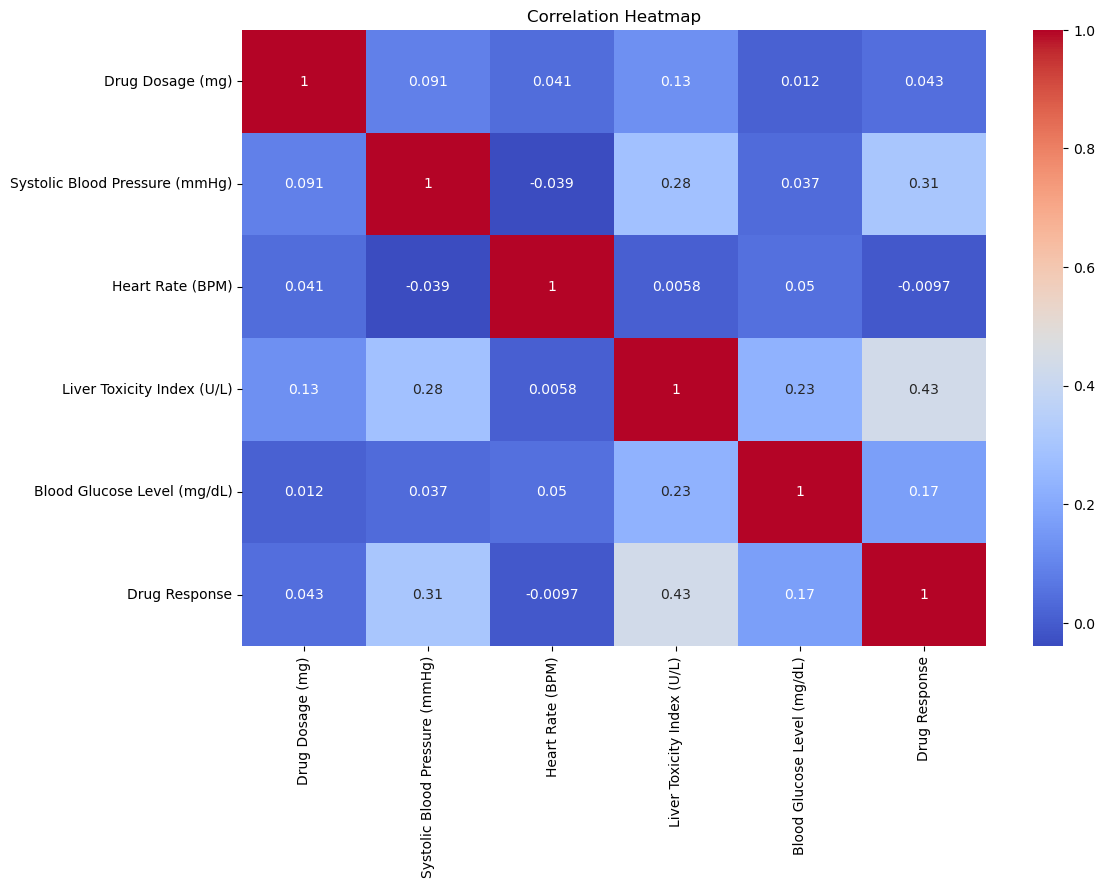

In [22]:
#Correlation Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

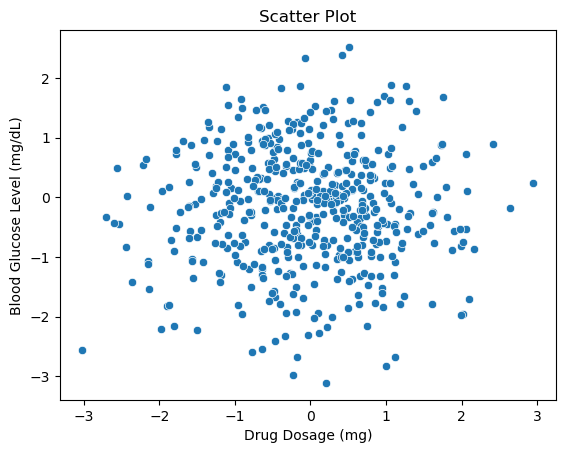

In [26]:
# Scatter Plot for Correlated Features (optional)
sns.scatterplot( x='Drug Dosage (mg)',y='Blood Glucose Level (mg/dL)', data=df)
plt.title("Scatter Plot")
plt.show()

<h5>Task 2: Data Preprocessing</h5>

In [27]:
df.select_dtypes(include='object').columns

Index([], dtype='object')

<h4>No categorical columns were found in the dataset. Therefore, encoding was not required before model training.</h4>

In [32]:
X = df[['Drug Dosage (mg)', 'Systolic Blood Pressure (mmHg)',
       'Heart Rate (BPM)', 'Liver Toxicity Index (U/L)',
       'Blood Glucose Level (mg/dL)']]

y = df['Drug Response']

In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X ,y, test_size=0.2,random_state=42)

<h6>Task 3: Data Visualization</h6>

<h5>Scatter Plot</h5>

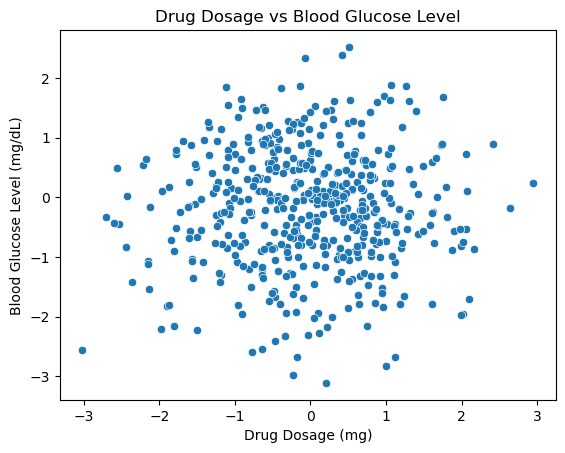

In [36]:
sns.scatterplot(x='Drug Dosage (mg)',y='Blood Glucose Level (mg/dL)',data=df)
plt.title("Drug Dosage vs Blood Glucose Level")
plt.show()

<h5>Pair Plot</h5>

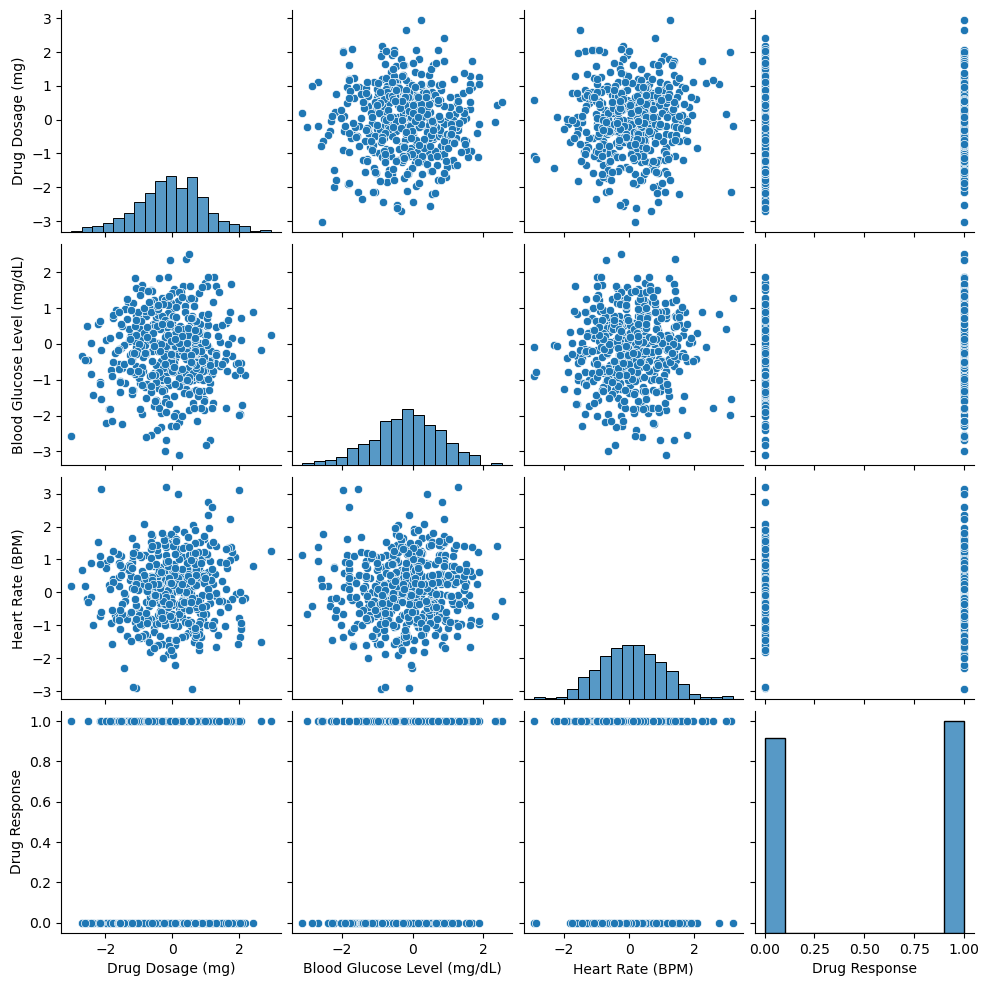

In [64]:
sns.pairplot(df[['Drug Dosage (mg)','Blood Glucose Level (mg/dL)','Heart Rate (BPM)', 'Drug Response']])
plt.show()

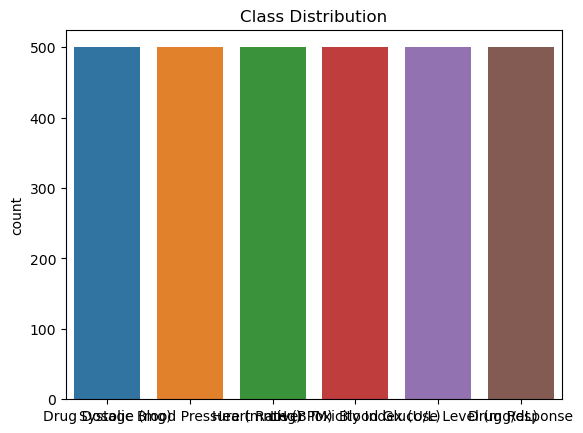

In [39]:
sns.countplot( data=df)

plt.title("Class Distribution")

plt.show()

<h6>Task 4: SVM Implementation</h6>

In [40]:
#Import SVM Model

from sklearn.svm import SVC

#Create SVM Model
svm_model = SVC(kernel='linear')

In [41]:
#Fit/Train Model
svm_model.fit(X_train, y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [42]:
#Make Predictions
y_pred = svm_model.predict(X_test)

In [43]:
# Import Evalution Metrics


from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
    

Accuracy : 0.78
Precision : 0.84
Recall : 0.75
F1 Score : 0.7924528301886793
              precision    recall  f1-score   support

           0       0.72      0.82      0.77        44
           1       0.84      0.75      0.79        56

    accuracy                           0.78       100
   macro avg       0.78      0.78      0.78       100
weighted avg       0.79      0.78      0.78       100



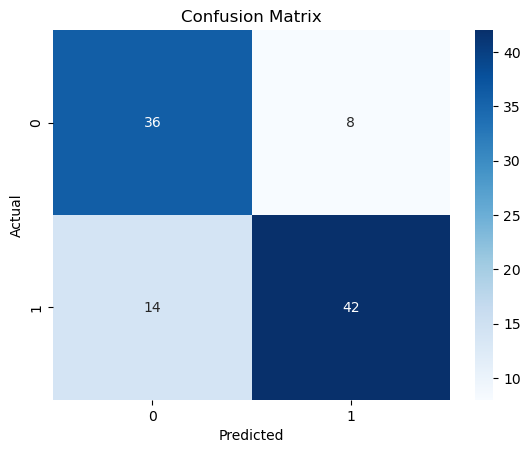

In [45]:
# Calculate Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy :", accuracy)

#Calculate Precision
precision = precision_score(y_test, y_pred)
print("Precision :", precision)

#Calculate Recall
recall = recall_score(y_test, y_pred)
print("Recall :", recall)

#Calculate F1-Score
f1 = f1_score(y_test, y_pred)
print("F1 Score :", f1)

#Classification Report
print(classification_report(y_test, y_pred))

#Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

<h6>Task 5: Visualization of SVM Results</h6>

In [46]:
#Import Required Libraries
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [47]:
#Create Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[36  8]
 [14 42]]


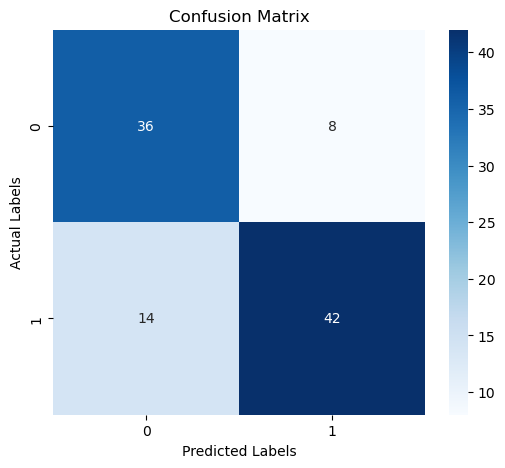

In [48]:
#Visualize Confusion Matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("Actual Labels")
plt.show()

<h6>Task 6: Parameter Tuning and Optimization</h6>

In [53]:
from sklearn.metrics import accuracy_score

In [54]:
# Linear kernel 
svm_linear = SVC( kernel='linear')
svm_linear.fit(X_train, y_train)
linear_pred = svm_linear.predict(X_test)

#Check Accuracy
print("Linear Kernel Accuracy :",accuracy_score(y_test, linear_pred))

Linear Kernel Accuracy : 0.78


In [56]:
#Polynomial Kernel
svm_poly = SVC(kernel='poly')
svm_poly.fit(X_train, y_train)
poly_pred = svm_poly.predict(X_test)

#Polynomial Accuracy
print("Polynomial Kernel Accuracy :",accuracy_score(y_test, poly_pred))

Polynomial Kernel Accuracy : 0.69


In [57]:
#RBF Kernel
svm_rbf = SVC(kernel='rbf')
svm_rbf.fit(X_train, y_train)
rbf_pred = svm_rbf.predict(X_test)

#RBF Accuracy
print("RBF Kernel Accuracy :",accuracy_score(y_test, rbf_pred))

RBF Kernel Accuracy : 0.82


In [58]:
#Tune Regularization Parameter (C)
svm_c = SVC(kernel='rbf',C=10)
svm_c.fit(X_train, y_train)
c_pred = svm_c.predict(X_test)
print("Accuracy with C=10 :",accuracy_score(y_test, c_pred))

Accuracy with C=10 : 0.78


In [59]:
#Tune Gamma Parameter
svm_gamma = SVC( kernel='rbf', gamma=0.1)
svm_gamma.fit(X_train, y_train)
gamma_pred = svm_gamma.predict(X_test)
print("Accuracy with gamma=0.1 :", accuracy_score(y_test, gamma_pred))

Accuracy with gamma=0.1 : 0.83


In [60]:
#Tune Both C and Gamma
svm_tuned = SVC(kernel='rbf',C=10,gamma=0.1)
svm_tuned.fit(X_train, y_train)
tuned_pred = svm_tuned.predict(X_test)
print("Tuned Model Accuracy :", accuracy_score(y_test, tuned_pred))

Tuned Model Accuracy : 0.83


In [62]:
#Accuracy Comparison
print("Linear Accuracy :", accuracy_score(y_test, linear_pred))

print("Polynomial Accuracy :", accuracy_score(y_test, poly_pred))

print("RBF Accuracy :", accuracy_score(y_test, rbf_pred))

print("Tuned Accuracy :", accuracy_score(y_test, tuned_pred))

Linear Accuracy : 0.78
Polynomial Accuracy : 0.69
RBF Accuracy : 0.82
Tuned Accuracy : 0.83


<h6>Task 7: Comparison and Analysis</h6>

In [63]:
print("Linear Kernel Accuracy :",
      accuracy_score(y_test, linear_pred))

print("Polynomial Kernel Accuracy :",
      accuracy_score(y_test, poly_pred))

print("RBF Kernel Accuracy :",
      accuracy_score(y_test, rbf_pred))

Linear Kernel Accuracy : 0.78
Polynomial Kernel Accuracy : 0.69
RBF Kernel Accuracy : 0.82


<h6>Among the tested kernels, the RBF kernel achieved better performance because it effectively handled non-linear relationships within the dataset.</h6>

2.	Analyze SVM strengths and weaknesses for the dataset based on EDA and visualization results.

<h4>Strengths</h4>

   <h6>SVM works well for high-dimensional datasets.
 Kernel functions allow non-linear classification.
 SVM provides strong generalization performance.</h6>

<h4>Weaknesses</h4>

   <h6>SVM training can be slow for large datasets.
Choosing optimal kernel and hyperparameters is difficult.
SVM models are less interpretable.</h6>

<h3>3.	Discuss practical implications of SVM in real-world classification tasks.</h3>

<h5>SVM is widely used in healthcare, image recognition, fraud detection, and pharmaceutical research for classification tasks.</h5>